# Customer & Campaign Intelligence — Data Cleaning

**Proyecto:** Segmentación de clientes y análisis de respuesta a campañas de marketing.

**Objetivo de este notebook:** aplicar las transformaciones de limpieza identificadas 
en la auditoría (`01_data_audit.ipynb`), corrigiendo outliers, valores nulos, categorías 
inválidas y tipos de dato, para dejar un dataset listo para el análisis.

**Entrada:** `data/raw/marketing_campaign.csv`
**Salida:** `data/processed/marketing_campaign_clean.csv`

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [24]:
df_clean = pd.read_csv("../data/raw/marketing_campaign.csv", sep=";")


In [25]:
df_clean.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [26]:
df_clean["Income"].isnull().sum()

np.int64(24)

In [27]:
median_income = df_clean["Income"].median()
df_clean["Income"] = df_clean["Income"].fillna(median_income)

In [28]:
df_clean["Income"].isnull().sum()

np.int64(0)

<Axes: ylabel='Year_Birth'>

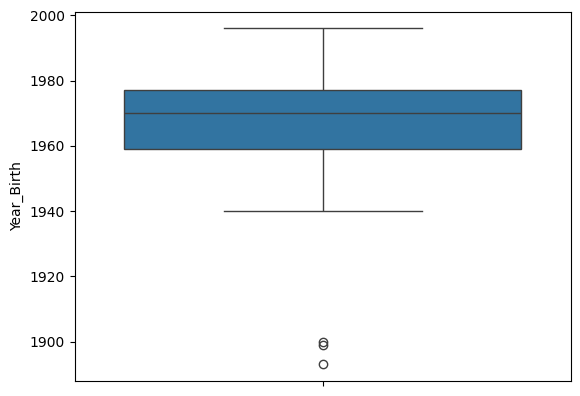

In [29]:
sns.boxplot(data=df_clean["Year_Birth"])

In [30]:
df_clean[df_clean["Year_Birth"] <= 1900]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
192,7829,1900,2n Cycle,Divorced,36640.0,1,0,2013-09-26,99,15,...,5,0,0,0,0,0,1,3,11,0
239,11004,1893,2n Cycle,Single,60182.0,0,1,2014-05-17,23,8,...,4,0,0,0,0,0,0,3,11,0
339,1150,1899,PhD,Together,83532.0,0,0,2013-09-26,36,755,...,1,0,0,1,0,0,0,3,11,0


In [31]:
def sin_outliers(df,col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3-q1
    limite_inferior = q1-1.5*IQR
    limite_superior = q3+1.5*IQR
    return df[(df[col]>=limite_inferior)&(df[col]<=limite_superior)]

outliers_year_birth = sin_outliers(df_clean,"Year_Birth")
df_clean = outliers_year_birth



<Axes: ylabel='Year_Birth'>

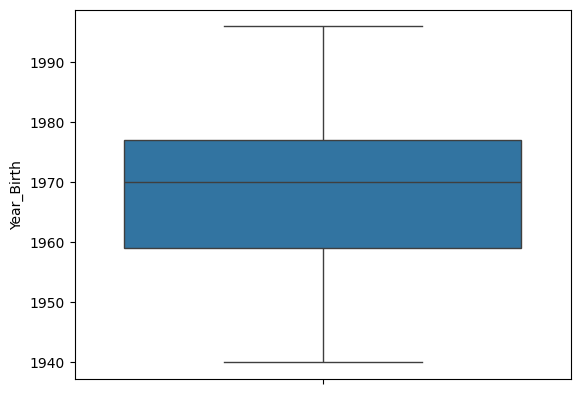

In [32]:


sns.boxplot(data=df_clean["Year_Birth"])

<Axes: ylabel='Income'>

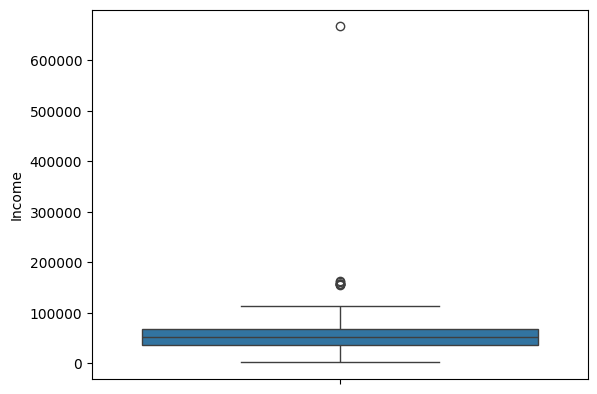

In [33]:
sns.boxplot(data=df_clean["Income"])

<Axes: ylabel='Income'>

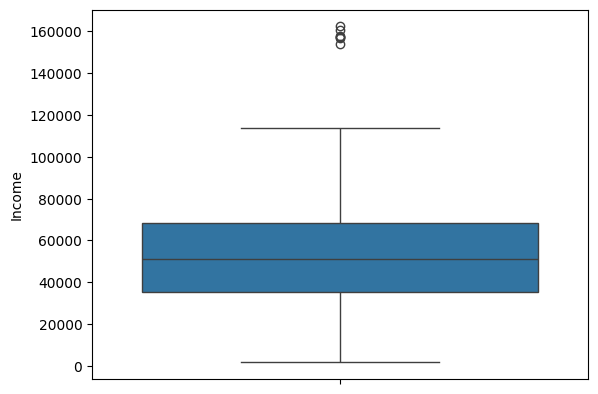

In [34]:
df_clean = df_clean[df_clean["Income"]<666666.0]

sns.boxplot(data=df_clean["Income"])



In [35]:
df_clean["Income"].max()

np.float64(162397.0)

In [36]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2236 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2236 non-null   int64  
 1   Year_Birth           2236 non-null   int64  
 2   Education            2236 non-null   object 
 3   Marital_Status       2236 non-null   object 
 4   Income               2236 non-null   float64
 5   Kidhome              2236 non-null   int64  
 6   Teenhome             2236 non-null   int64  
 7   Dt_Customer          2236 non-null   object 
 8   Recency              2236 non-null   int64  
 9   MntWines             2236 non-null   int64  
 10  MntFruits            2236 non-null   int64  
 11  MntMeatProducts      2236 non-null   int64  
 12  MntFishProducts      2236 non-null   int64  
 13  MntSweetProducts     2236 non-null   int64  
 14  MntGoldProds         2236 non-null   int64  
 15  NumDealsPurchases    2236 non-null   int64 

In [37]:
df_clean["Marital_Status"] = df_clean["Marital_Status"].replace("Alone","Single")
df_clean["Marital_Status"] = df_clean["Marital_Status"].replace("Absurd","Single")
df_clean["Marital_Status"] = df_clean["Marital_Status"].replace("YOLO","Single")

C:\Users\Eva 01\AppData\Local\Temp\ipykernel_2128\4252944272.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Marital_Status"] = df_clean["Marital_Status"].replace("Alone","Single")
C:\Users\Eva 01\AppData\Local\Temp\ipykernel_2128\4252944272.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Marital_Status"] = df_clean["Marital_Status"].replace("Absurd","Single")
C:\Users\Eva 01\AppData\Local\Temp\ipykernel_2128\4252944272.py:3: SettingWithCopyWarning: 
A value is trying to be set o

In [38]:
df_clean["Marital_Status"].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow'], dtype=object)

In [39]:
df_clean["Dt_Customer"] = pd.to_datetime(df_clean["Dt_Customer"])

C:\Users\Eva 01\AppData\Local\Temp\ipykernel_2128\1441520306.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Dt_Customer"] = pd.to_datetime(df_clean["Dt_Customer"])


In [40]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2236 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2236 non-null   int64         
 1   Year_Birth           2236 non-null   int64         
 2   Education            2236 non-null   object        
 3   Marital_Status       2236 non-null   object        
 4   Income               2236 non-null   float64       
 5   Kidhome              2236 non-null   int64         
 6   Teenhome             2236 non-null   int64         
 7   Dt_Customer          2236 non-null   datetime64[ns]
 8   Recency              2236 non-null   int64         
 9   MntWines             2236 non-null   int64         
 10  MntFruits            2236 non-null   int64         
 11  MntMeatProducts      2236 non-null   int64         
 12  MntFishProducts      2236 non-null   int64         
 13  MntSweetProducts     2236 non-null   i

In [41]:
df_clean = df_clean.drop(columns=["Z_CostContact", "Z_Revenue"])

In [42]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2236 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2236 non-null   int64         
 1   Year_Birth           2236 non-null   int64         
 2   Education            2236 non-null   object        
 3   Marital_Status       2236 non-null   object        
 4   Income               2236 non-null   float64       
 5   Kidhome              2236 non-null   int64         
 6   Teenhome             2236 non-null   int64         
 7   Dt_Customer          2236 non-null   datetime64[ns]
 8   Recency              2236 non-null   int64         
 9   MntWines             2236 non-null   int64         
 10  MntFruits            2236 non-null   int64         
 11  MntMeatProducts      2236 non-null   int64         
 12  MntFishProducts      2236 non-null   int64         
 13  MntSweetProducts     2236 non-null   i

In [43]:
print("Filas finales:", df_clean.shape[0])
print("Columnas finales:", df_clean.shape[1])
print("Nulos en Income:", df_clean["Income"].isnull().sum())
print("Máximo en Income:", df_clean["Income"].max())

Filas finales: 2236
Columnas finales: 27
Nulos en Income: 0
Máximo en Income: 162397.0


In [44]:
df_clean.to_csv("../data/processed/marketing_campaign_clean.csv", index=False)

## Limpieza de Datos — Resumen

A partir de los hallazgos documentados en `01_data_audit.ipynb`, se aplicaron 
las siguientes transformaciones sobre el dataset original (2,240 filas × 29 columnas):

1. **Year_Birth:** se eliminaron 3 registros con años de nacimiento imposibles 
   (1893, 1899, 1900), usando el método IQR (rango intercuartílico) para 
   detectar valores atípicos.
2. **Income:** se imputaron 24 valores nulos con la mediana (antes de cualquier 
   filtro, para no perderlos por accidente), y se eliminó 1 registro con un 
   valor extremo (666,666), identificado manualmente al comparar contra el 
   resto de la distribución.
3. **Marital_Status:** las categorías inválidas (`Alone`, `Absurd`, `YOLO`) 
   se fusionaron con `Single`.
4. **Dt_Customer:** se convirtió de texto (`object`) a fecha (`datetime64`).
5. **Z_CostContact y Z_Revenue:** se eliminaron por ser columnas constantes, 
   sin valor analítico.

**Nota metodológica:** para `Income`, se optó por un filtro manual en vez del 
método IQR automático, ya que este último marcaba como outliers a clientes de 
alto ingreso genuinos (sin saltos abruptos entre ellos), no solo al valor 
erróneo real (666,666).

**Resultado final:** 2,236 filas × 27 columnas, guardado en 
`data/processed/marketing_campaign_clean.csv`.